# Ecommerce Linear Regression Project

This notebook covers an end-to-end **Linear Regression** use case using ecommerce data.

## Objective
Predict **sales_amount** based on:
- categorical features
- numerical features
- basic preprocessing
- model training
- evaluation
- prediction on new input

---


## Task 1: Import libraries

Load all required Python libraries for:
- data handling
- preprocessing
- model building
- evaluation


In [41]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


## Task 2: Read the ecommerce CSV file

In [42]:
df=pd.read_csv('ecommerce_regression_data.csv')
df

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1,1307.65
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1,2605.51
2,Home,Business,UPI,7,22,2531.15,4.5,2,0,2530.16
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0,1719.26
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0,2131.67
...,...,...,...,...,...,...,...,...,...,...
995,Beauty,Regular,Card,7,0,2256.20,4.3,1,0,2399.03
996,Fashion,Prime,UPI,6,22,2287.48,3.7,0,0,2099.94
997,Home,Regular,Card,4,40,1839.05,4.1,0,0,1372.51
998,Fashion,Regular,Wallet,10,11,2936.58,3.3,2,0,2717.77


## Task 3: Check shape and column names

In [43]:
df.shape

(1000, 10)

In [44]:
df.columns

Index(['product_category', 'customer_segment', 'payment_method', 'units_sold',
       'discount_pct', 'ad_spend', 'customer_rating', 'returns_count',
       'is_festival_season', 'sales_amount'],
      dtype='str')

## Task 4: Explore dataset information and missing values

In [45]:
df.isna().any()

product_category       True
customer_segment       True
payment_method         True
units_sold            False
discount_pct          False
ad_spend               True
customer_rating        True
returns_count         False
is_festival_season    False
sales_amount          False
dtype: bool

In [46]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
print(cat_cols)

Index(['product_category', 'customer_segment', 'payment_method'], dtype='str')


C:\Users\N.Nikhitha\AppData\Local\Temp\ipykernel_29816\1312351319.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


In [47]:
df['units_sold'] = df['units_sold'].fillna(df['units_sold'].mean())
df['discount_pct'] = df['discount_pct'].fillna(df['discount_pct'].mean())
df['returns_count'] = df['returns_count'].fillna(df['returns_count'].mean())
df['is_festival_season'] = df['is_festival_season'].fillna(df['is_festival_season'].mean())
df['sales_amount'] = df['sales_amount'].fillna(df['sales_amount'].mean())

In [48]:
df

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1,1307.65
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1,2605.51
2,Home,Business,UPI,7,22,2531.15,4.5,2,0,2530.16
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0,1719.26
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0,2131.67
...,...,...,...,...,...,...,...,...,...,...
995,Beauty,Regular,Card,7,0,2256.20,4.3,1,0,2399.03
996,Fashion,Prime,UPI,6,22,2287.48,3.7,0,0,2099.94
997,Home,Regular,Card,4,40,1839.05,4.1,0,0,1372.51
998,Fashion,Regular,Wallet,10,11,2936.58,3.3,2,0,2717.77


## Task 5: Summary statistics

In [49]:
df.describe()

,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
count,1000.000000,1000.000000,985.000000,985.000000,1000.000000,1000.000000,1000.000000
mean,5.531000,19.874000,2430.335766,4.105076,1.438000,0.225000,2146.947540
std,2.878076,11.948678,911.384942,0.488771,1.124019,0.417791,552.016871
min,1.000000,0.000000,200.000000,2.600000,0.000000,0.000000,423.460000
25%,3.000000,10.000000,1832.030000,3.800000,0.000000,0.000000,1764.660000
50%,6.000000,20.000000,2464.260000,4.100000,1.000000,0.000000,2141.540000
75%,8.000000,30.000000,3052.840000,4.500000,2.000000,0.000000,2550.967500
max,10.000000,40.000000,5122.820000,5.000000,3.000000,1.000000,3776.170000


## Task 6: Define target and input features

Target column:
- `sales_amount`

Input columns:
- all remaining columns


In [50]:
X = df.drop(columns='sales_amount')
y = df['sales_amount']


## Task 7: Build preprocessing pipelines

### For categorical columns
- fill missing values with most frequent value
- apply one-hot encoding

### For numerical columns
- fill missing values with median


In [51]:
df = pd.get_dummies(df, columns=["product_category","customer_segment","payment_method"])

bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [52]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Task 8: Split data into train and test sets

In [56]:
# Split the data into training and testing sets
X = df.drop('sales_amount',axis=1)

y = df['sales_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 18), (200, 18), (800,), (200,))

## Task 9: Create Linear Regression model pipeline

In [57]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [58]:
X.isna().sum()

units_sold                      0
discount_pct                    0
ad_spend                        0
customer_rating                 0
returns_count                   0
is_festival_season              0
product_category_Beauty         0
product_category_Electronics    0
product_category_Fashion        0
product_category_Home           0
product_category_Sports         0
customer_segment_Business       0
customer_segment_Prime          0
customer_segment_Regular        0
payment_method_Card             0
payment_method_NetBanking       0
payment_method_UPI              0
payment_method_Wallet           0
dtype: int64

## Task 10: Make predictions on test data

In [59]:
y_pred = model.predict(X_test)

## Task 11: Evaluate the model

In [60]:
print(f'Intercept: {model.intercept_}')
print(f'Coefficients: {model.coef_}')

Intercept: 734.7853951999643
Coefficients: [ 97.09216435 -18.08658577   0.41956271  72.39993522 -43.18156267
 130.6390197  -86.42679968  38.59448425 -69.91749426 -65.29336563
 -21.11066491  87.5190953   41.32392498 -31.63442612 -29.09326407
 -21.55250915  -5.29085393 -13.2521845 ]


In [61]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Mean Absolute Error: 97.94653053603521
R-squared: 0.9451040411678587


## Task 12: Visualize Actual vs Predicted

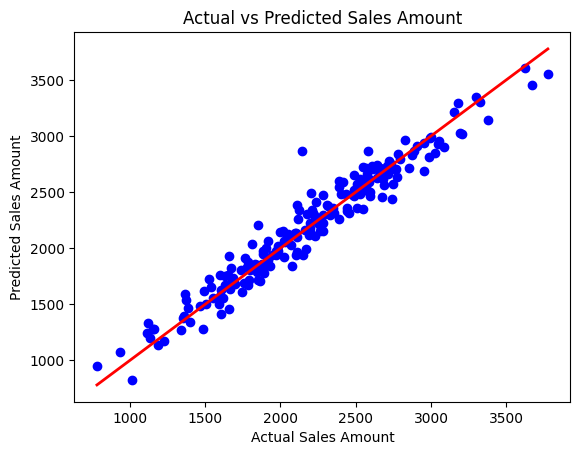

In [62]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Sales Amount')
plt.ylabel('Predicted Sales Amount')
plt.title('Actual vs Predicted Sales Amount')
plt.show()

## Task 13: Residual analysis

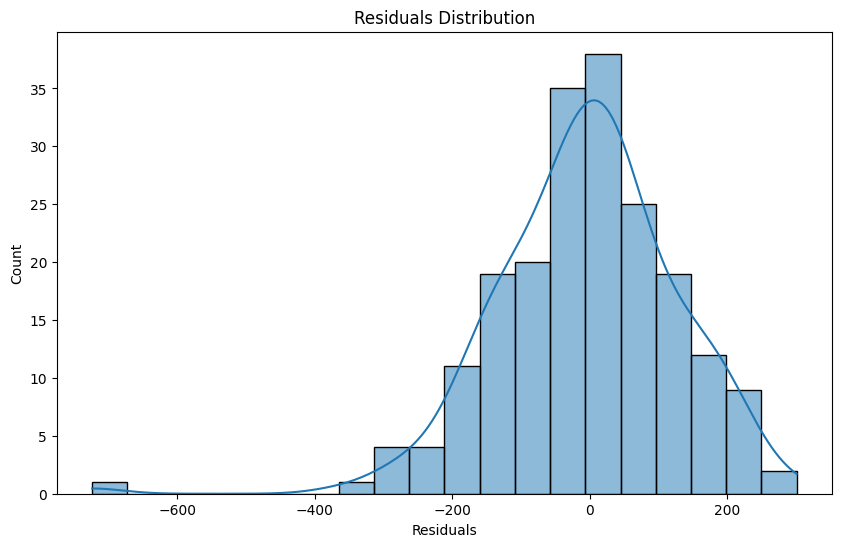

In [63]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True)
plt.xlabel('Residuals')
plt.title('Residuals Distribution')
plt.show()


## Task 14: Predict sales for a new ecommerce record

In [ ]:
new_record = pd.DataFrame([{
    "product_category": "Beauty",
    "customer_segment": "Regular",
    "payment_method": "UPI",
    "units_sold": 5,
    "discount_pct": 10,
    "ad_spend": 3000.0,
    "customer_rating": 4.2,
    "returns_count": 0,
    "is_festival_season": 1
}])
 

In [68]:
new_pred = model.predict(new_record)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- customer_segment
- payment_method
- product_category
Feature names seen at fit time, yet now missing:
- customer_segment_Business
- customer_segment_Prime
- customer_segment_Regular
- payment_method_Card
- payment_method_NetBanking
- ...
